<a href="https://colab.research.google.com/github/Vnshk-sharma/customer_segmentation_and_churn_prediction/blob/main/Customer_Segmentation_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation and Churn Prediction
### Telco Customer Dataset — Internship Project

**Objective:**
This project analyzes a telecom company's customer base to:
1. Perform exploratory data analysis (EDA) to understand churn drivers.
2. Segment customers into distinct groups using unsupervised machine learning (K-Means clustering) based on behavioral and value attributes.
3. Build and evaluate supervised machine learning models to predict customer churn.
4. Combine both analyses to generate actionable, segment-specific business recommendations.

**Dataset:** IBM Telco Customer Churn dataset — 7,043 customers, 33 attributes including demographics, account information, subscribed services, billing, and churn status.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost.


## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


## 2. Load the Dataset

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")
print("Shape:", df.shape)
df.head()


Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## 3. Data Cleaning & Preprocessing

Key cleaning steps:
- `Total Charges` is stored as text and contains blank values for customers with 0 tenure (new customers) — convert to numeric.
- Drop identifier / geographic columns that add no predictive value for a general model (`CustomerID`, `Count`, `Country`, `Lat Long`, `Zip Code`, etc.).
- Drop **`Churn Label`** (a duplicate of `Churn Value`), **`Churn Score`** (this is IBM's own pre-computed churn risk score — using it as a feature would leak the answer), and **`Churn Reason`** (only known *after* a customer has already churned, so it cannot be used to *predict* churn in advance).


In [ ]:
# Convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print("Missing Total Charges after conversion:", df["Total Charges"].isna().sum())

# These are all customers with 0 tenure (just joined) -> total charges = 0
df.loc[df["Total Charges"].isna(), "Tenure Months"].unique()


Missing Total Charges after conversion: 11


array([0])

In [ ]:
df["Total Charges"] = df["Total Charges"].fillna(0)

# Columns to drop: identifiers, geography, and leakage columns
drop_cols = ["CustomerID", "Count", "Country", "State", "City", "Zip Code",
             "Lat Long", "Latitude", "Longitude",
             "Churn Label", "Churn Score", "Churn Reason"]
df_clean = df.drop(columns=drop_cols)

print("Remaining columns:", df_clean.shape[1])
df_clean.head()


Remaining columns: 21


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


In [ ]:
# Check for any remaining missing values
df_clean.isna().sum()[df_clean.isna().sum() > 0]


Series([], dtype: int64)

## 4. Exploratory Data Analysis (EDA)

Overall churn rate: 26.54%


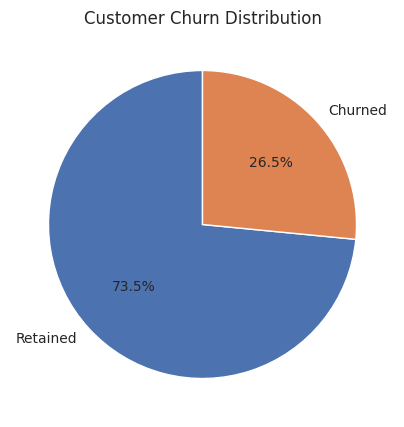

In [ ]:
churn_rate = df_clean["Churn Value"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

plt.figure(figsize=(5,5))
df_clean["Churn Value"].value_counts().plot(
    kind="pie", labels=["Retained", "Churned"], autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"], startangle=90)
plt.ylabel("")
plt.title("Customer Churn Distribution")
plt.show()


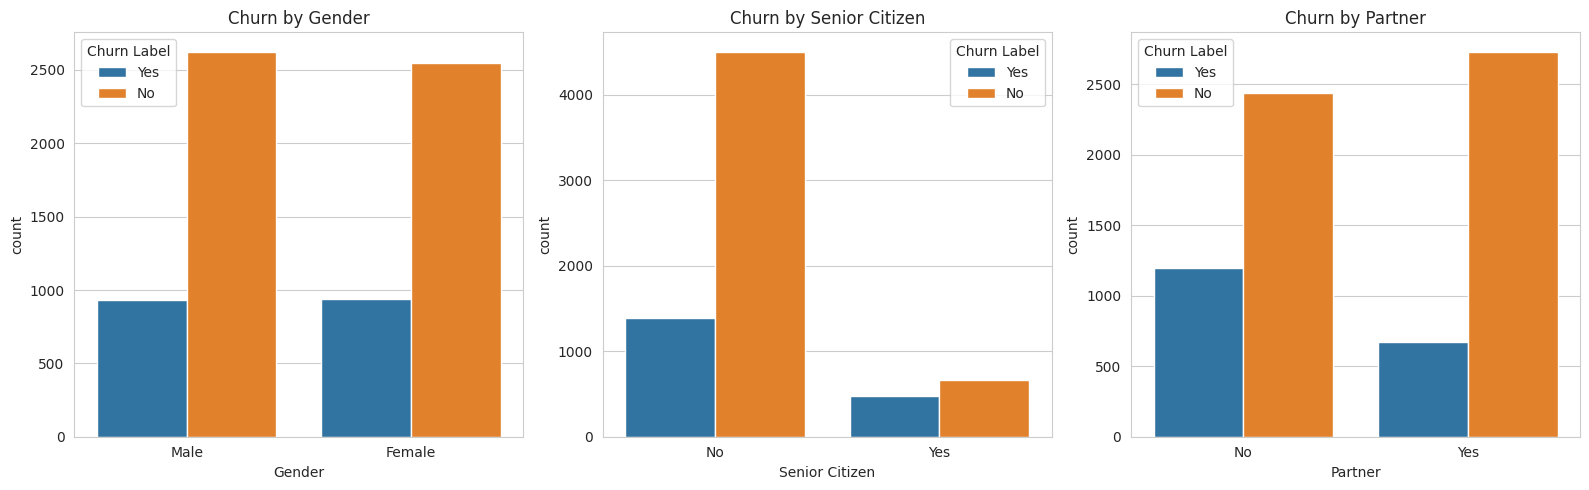

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Note: "Churn Label" was dropped from df_clean above (duplicate of Churn Value),
# so we use the original df here to get the human-readable Retained/Churned hue.
for ax, col in zip(axes, ["Gender", "Senior Citizen", "Partner"]):
    sns.countplot(data=df, x=col, hue="Churn Label", ax=ax)
    ax.set_title(f"Churn by {col}")
plt.tight_layout()
plt.show()


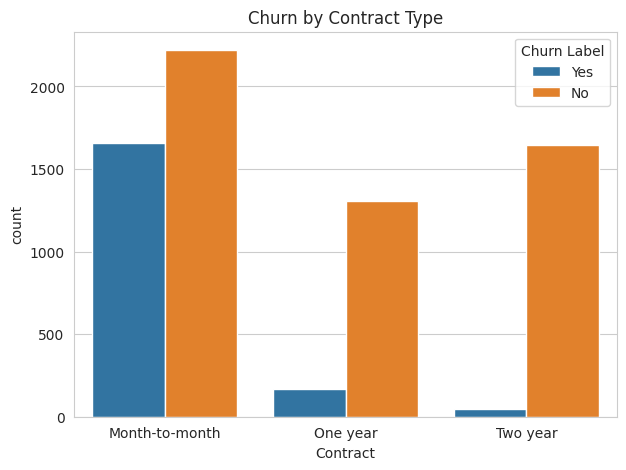

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Contract", hue="Churn Label",
              order=["Month-to-month", "One year", "Two year"])
plt.title("Churn by Contract Type")
plt.show()


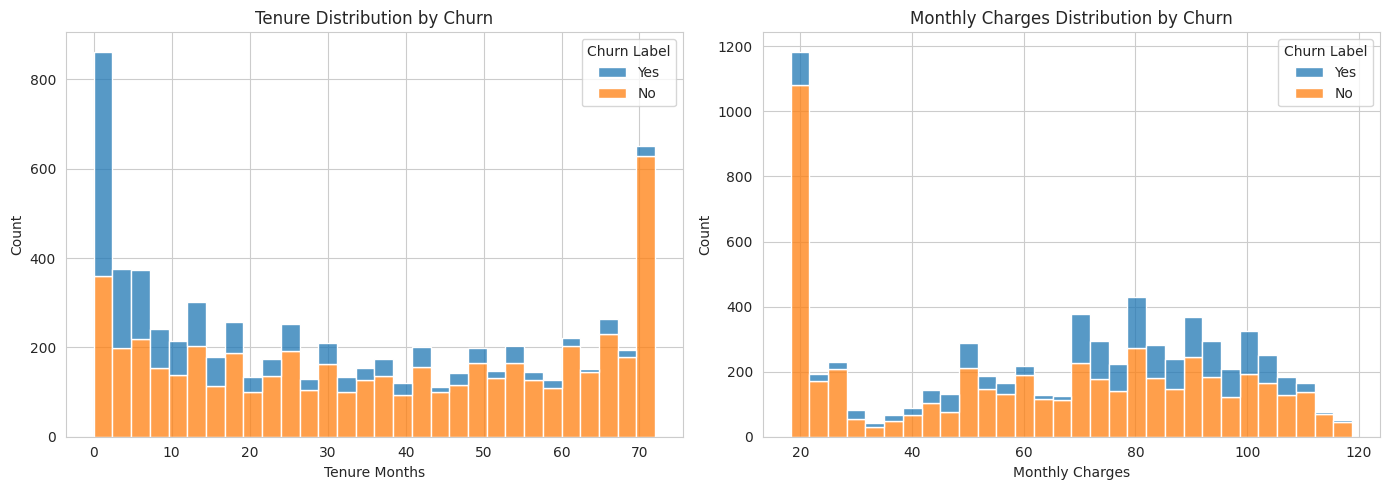

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(data=df, x="Tenure Months", hue="Churn Label", multiple="stack",
             bins=30, ax=axes[0])
axes[0].set_title("Tenure Distribution by Churn")

sns.histplot(data=df, x="Monthly Charges", hue="Churn Label", multiple="stack",
             bins=30, ax=axes[1])
axes[1].set_title("Monthly Charges Distribution by Churn")
plt.tight_layout()
plt.show()


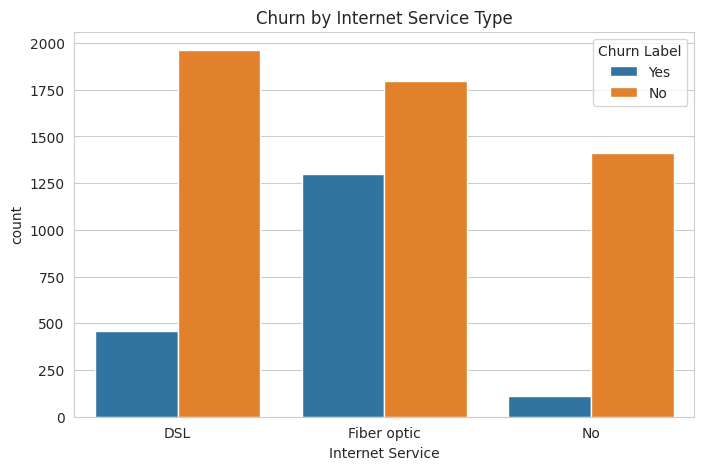

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Internet Service", hue="Churn Label")
plt.title("Churn by Internet Service Type")
plt.show()


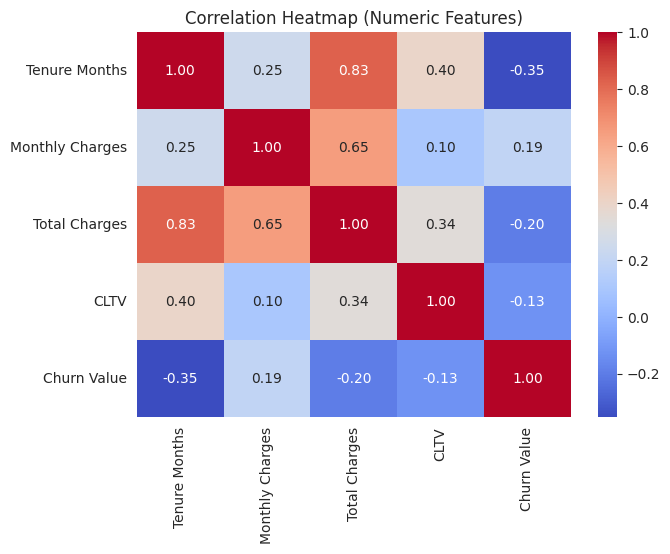

In [ ]:
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV", "Churn Value"]
plt.figure(figsize=(7,5))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


**Key EDA observations** :
- The dataset has a class imbalance (~26-27% churn rate), which is handled later using `class_weight="balanced"` and stratified train/test splitting.
- Customers on **month-to-month contracts** churn far more than those on one/two-year contracts.
- **Lower tenure** customers churn more — risk drops sharply after the first year.
- **Fiber optic** internet customers show higher churn than DSL or no-internet customers.
- **Tenure** and **Total Charges** are highly correlated (longer-tenured customers have paid more in total), which is expected and is accounted for during feature selection.


## 5. Customer Segmentation (Unsupervised Learning)

We segment customers using an RFM-inspired approach adapted for a subscription business:
- **Tenure Months** — how long the customer has stayed (recency/loyalty proxy)
- **Monthly Charges** — current spend level (frequency/value proxy)
- **Total Charges** — cumulative value to the business (monetary)
- **CLTV** — Customer Lifetime Value score provided in the dataset

These features are scaled and clustered using **K-Means**.


In [ ]:
seg_features = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]
X_seg = df_clean[seg_features].copy()

scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)


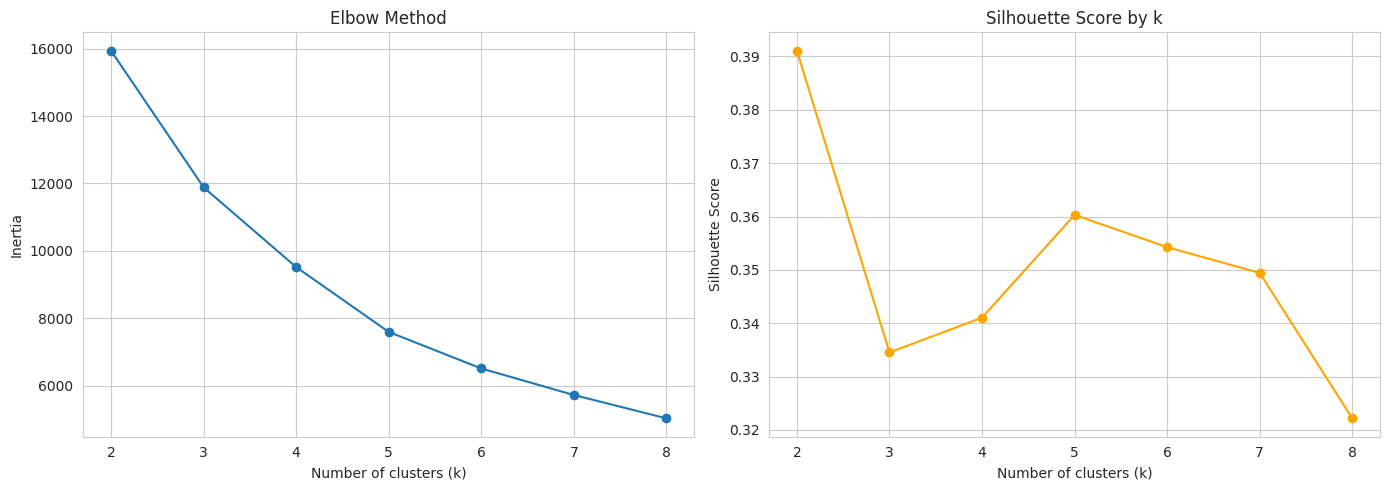

{2: np.float64(0.391), 3: np.float64(0.335), 4: np.float64(0.341), 5: np.float64(0.36), 6: np.float64(0.354), 7: np.float64(0.349), 8: np.float64(0.322)}


In [ ]:
# Elbow method + silhouette score to choose number of clusters
inertias, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_seg_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_seg_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

print(dict(zip(K_range, np.round(sil_scores, 3))))


In [ ]:
# Based on the elbow + silhouette plots, k=4 gives a good balance of
# compactness and interpretability for business segmentation
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df_clean["Segment"] = kmeans.fit_predict(X_seg_scaled)

df_clean["Segment"].value_counts().sort_index()


Segment
0    1916
1    1947
2    2171
3    1009
Name: count, dtype: int64

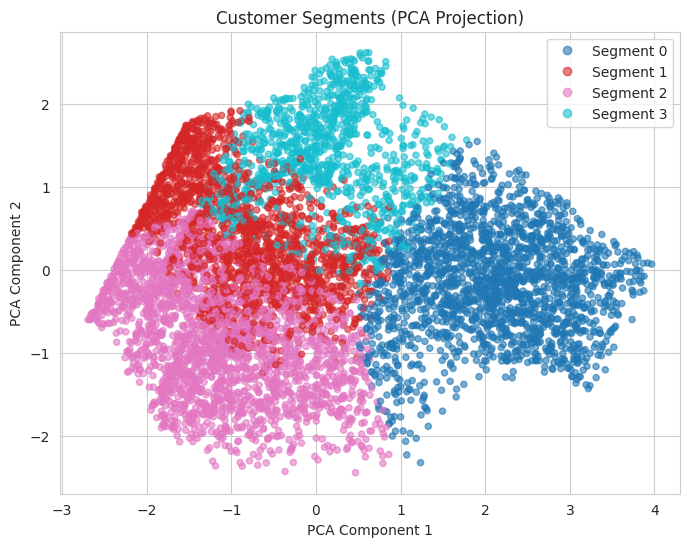

Explained variance by 2 PCA components: 83.2%


In [ ]:
# Visualize clusters in 2D using PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
seg_pca = pca.fit_transform(X_seg_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(seg_pca[:,0], seg_pca[:,1], c=df_clean["Segment"],
                       cmap="tab10", alpha=0.6, s=20)
plt.title("Customer Segments (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(handles=scatter.legend_elements()[0],
           labels=[f"Segment {i}" for i in range(N_CLUSTERS)])
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.1f}%")


In [ ]:
# Profile each segment
segment_profile = df_clean.groupby("Segment")[seg_features + ["Churn Value"]].mean().round(2)
segment_profile["Customer Count"] = df_clean["Segment"].value_counts().sort_index()
segment_profile = segment_profile.rename(columns={"Churn Value": "Churn Rate"})
segment_profile


,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Rate,Customer Count
Segment,,,,,,
0,59.18,93.20,5506.27,5100.79,0.16,1916
1,11.01,57.57,682.33,4973.25,0.39,1947
2,17.56,61.12,1103.47,2942.55,0.35,2171
3,54.54,32.48,1766.11,5101.08,0.04,1009


/tmp/ipykernel_642/4054271228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Segment", y="Tenure Months", ax=axes[0], palette="tab10")
/tmp/ipykernel_642/4054271228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Segment", y="Monthly Charges", ax=axes[1], palette="tab10")


/tmp/ipykernel_642/4054271228.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Segment", y="Churn Value", ax=axes[2], palette="tab10")


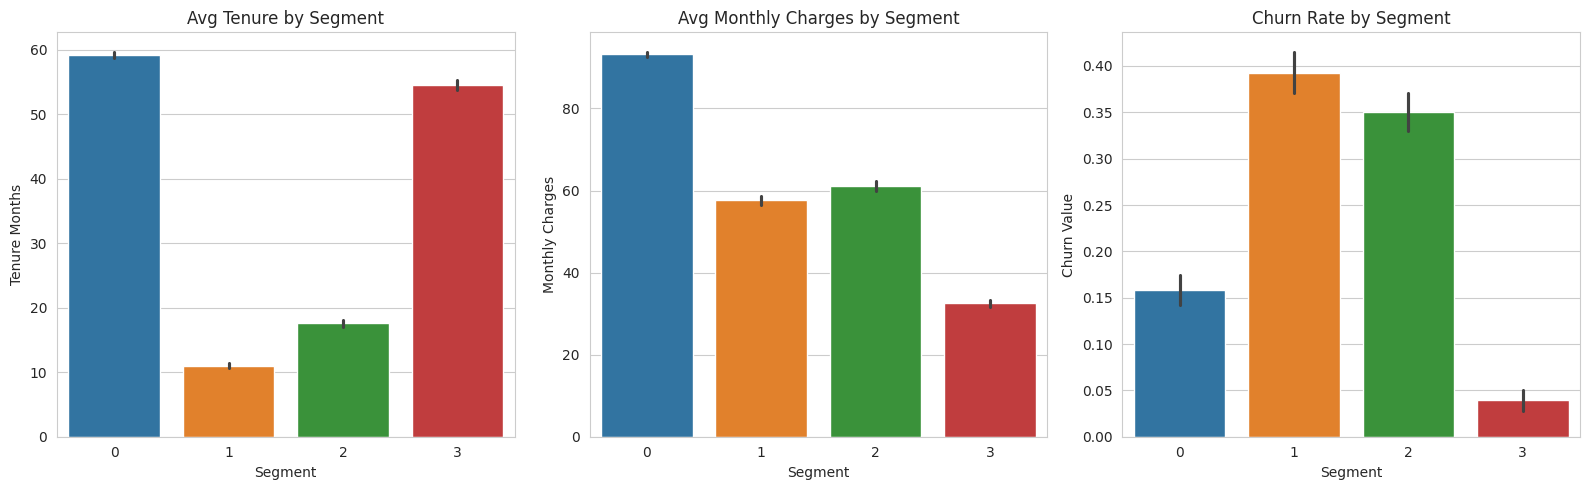

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.barplot(data=df_clean, x="Segment", y="Tenure Months", ax=axes[0], palette="tab10")
axes[0].set_title("Avg Tenure by Segment")
sns.barplot(data=df_clean, x="Segment", y="Monthly Charges", ax=axes[1], palette="tab10")
axes[1].set_title("Avg Monthly Charges by Segment")
sns.barplot(data=df_clean, x="Segment", y="Churn Value", ax=axes[2], palette="tab10")
axes[2].set_title("Churn Rate by Segment")
plt.tight_layout()
plt.show()


**Interpreting the segments** (based on this run's `segment_profile` output):

| Segment | Tenure | Monthly Charges | CLTV | Churn Rate | Label |
|---|---|---|---|---|---|
| 0 | High (~59 mo) | High (~$93) | High (~5,100) | Low (~16%) | **"Loyal High-Value"** |
| 1 | Low (~11 mo) | Mid (~$58) | High (~4,970) | **High (~39%)** | **"At-Risk Newcomers"** |
| 2 | Mid (~18 mo) | Mid (~$61) | Low (~2,940) | High (~35%) | **"Low-CLTV Flight Risks"** |
| 3 | High (~55 mo) | Low (~$32) | High (~5,100) | **Very Low (~4%)** | **"Stable Budget Loyalists"** |

Segments 1 and 2 together account for the majority of churn risk — newer customers (Segment 1) and mid-tenure customers who haven't built up lifetime value yet (Segment 2). Segments 0 and 3 are the company's most stable, retained base.


## 6. Churn Prediction (Supervised Learning)

We now build classification models to predict `Churn Value` (1 = churned, 0 = retained) using customer demographics, services, and billing information. `Segment` from the clustering step is also included as an engineered feature.


In [ ]:
model_df = df_clean.drop(columns=["CLTV"])  # CLTV often correlates strongly with tenure/spend; keep model focused on actionable service/account features
target = "Churn Value"

cat_cols = model_df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols]
print("Categorical columns to encode:", cat_cols)

model_encoded = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)
print("Final feature matrix shape:", model_encoded.shape)


Categorical columns to encode: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Final feature matrix shape: (7043, 32)


/tmp/ipykernel_642/3996852958.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include="object").columns.tolist()


In [ ]:
X = model_encoded.drop(columns=[target])
y = model_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train churn rate: %.2f%%  Test churn rate: %.2f%%" %
      (y_train.mean()*100, y_test.mean()*100))


Train size: (5634, 31)  Test size: (1409, 31)
Train churn rate: 26.54%  Test churn rate: 26.54%


In [ ]:
scaler = StandardScaler()
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                             random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric="logloss", random_state=RANDOM_STATE)
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, proba)
    })
    fitted_models[name] = (model, preds, proba)

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df.sort_values("ROC AUC", ascending=False)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.743,0.510,0.781,0.617,0.849
XGBoost,0.751,0.521,0.770,0.621,0.847
Random Forest,0.799,0.655,0.513,0.576,0.839


In [ ]:
best_model_name = results_df["ROC AUC"].idxmax()
print("Best model by ROC-AUC:", best_model_name)

best_model, best_preds, best_proba = fitted_models[best_model_name]

print(classification_report(y_test, best_preds, target_names=["Retained","Churned"]))


Best model by ROC-AUC: Logistic Regression
              precision    recall  f1-score   support

    Retained       0.90      0.73      0.81      1035
     Churned       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



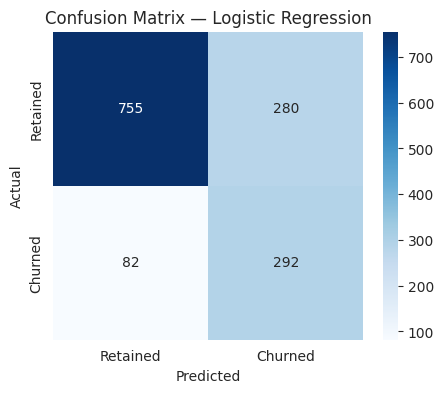

In [ ]:
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


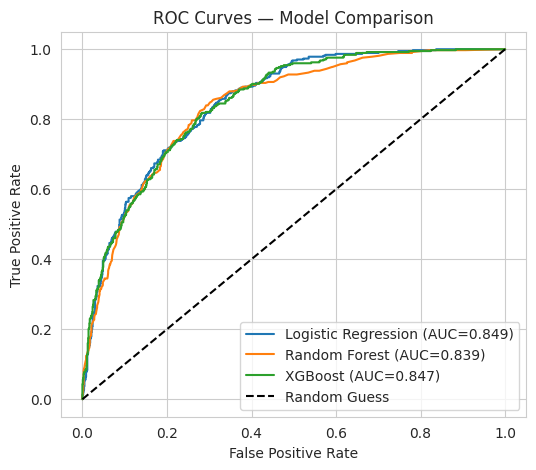

In [ ]:
plt.figure(figsize=(6,5))
for name, (model, preds, proba) in fitted_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()


/tmp/ipykernel_642/897136523.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[top_features].values, y=top_features, palette="viridis")


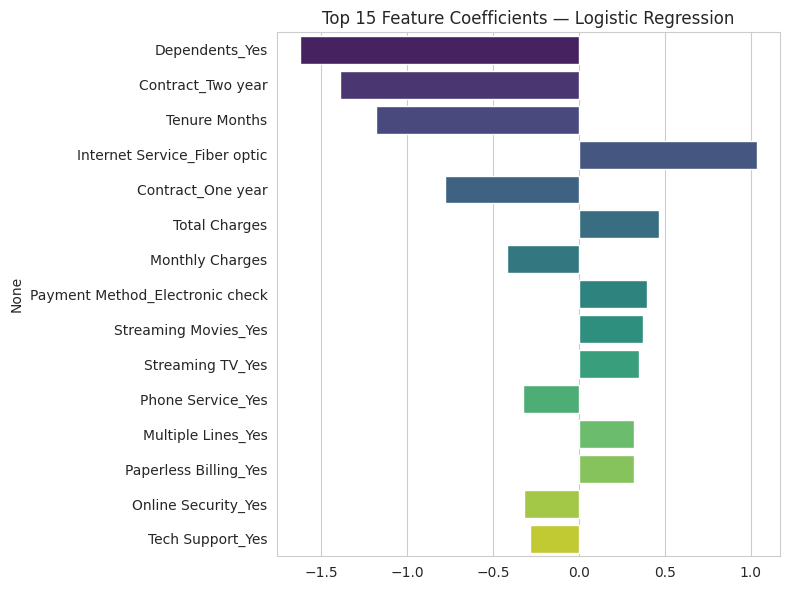

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_features = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8,6))
    sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_[0], index=X.columns)
    top_features = coefs.abs().sort_values(ascending=False).head(15).index
    plt.figure(figsize=(8,6))
    sns.barplot(x=coefs[top_features].values, y=top_features, palette="viridis")
    plt.title(f"Top 15 Feature Coefficients — {best_model_name}")
    plt.tight_layout()
    plt.show()


**Model performance summary:** Logistic Regression and XGBoost both reach **ROC-AUC ≈ 0.85**, slightly ahead of Random Forest (≈0.84). Logistic Regression and XGBoost recall churned customers well (Recall ≈ 0.77–0.78), which matters most here — missing an at-risk customer is costlier than a false alarm. Random Forest trades recall for higher precision/accuracy. `Contract` type, `Tenure Months`, `Internet Service` (Fiber optic), and `Monthly Charges` emerge as the strongest churn predictors — consistent with the EDA findings.


## 7. Combining Segmentation and Churn Prediction

Linking the unsupervised segments back to churn outcomes helps translate model output into a targeted retention strategy.


In [ ]:
segment_churn = df_clean.groupby("Segment").agg(
    Customers=("Churn Value", "size"),
    Churn_Rate=("Churn Value", "mean"),
    Avg_Monthly_Charges=("Monthly Charges", "mean"),
    Avg_Tenure=("Tenure Months", "mean"),
    Avg_CLTV=("CLTV", "mean")
).round(2)
segment_churn["Churn_Rate"] = (segment_churn["Churn_Rate"]*100).round(1)
segment_churn.sort_values("Churn_Rate", ascending=False)


,Customers,Churn_Rate,Avg_Monthly_Charges,Avg_Tenure,Avg_CLTV
Segment,,,,,
1,1947,39.0,57.57,11.01,4973.25
2,2171,35.0,61.12,17.56,2942.55
0,1916,16.0,93.20,59.18,5100.79
3,1009,4.0,32.48,54.54,5101.08


/tmp/ipykernel_642/2740901155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_churn.index, y=segment_churn["Churn_Rate"], palette="tab10")


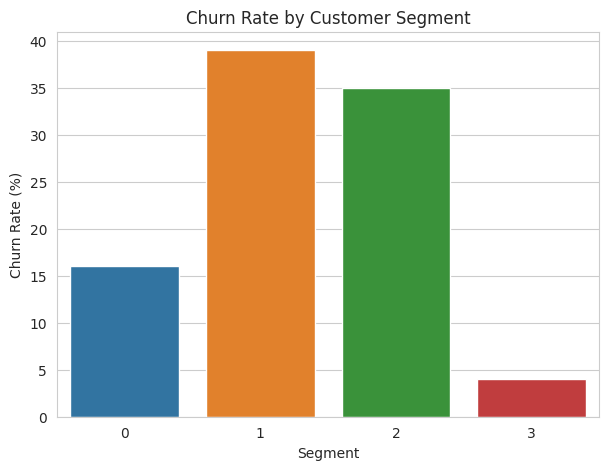

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x=segment_churn.index, y=segment_churn["Churn_Rate"], palette="tab10")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Segment")
plt.title("Churn Rate by Customer Segment")
plt.show()


## 8. Conclusion & Business Recommendations

**Summary of findings:**
- Overall churn rate is **26.5%**, concentrated heavily among month-to-month contract customers and those in their first year of tenure.
- K-Means clustering on tenure, billing, and CLTV revealed four segments with very different risk profiles — from a **"Stable Budget Loyalists"** segment churning at only ~4%, to an **"At-Risk Newcomers"** segment churning at ~39%.
- The best churn models (Logistic Regression / XGBoost) achieve **ROC-AUC ≈ 0.85** with recall ≈ 0.78 for churned customers, with contract type, tenure, fiber-optic internet, and monthly charges as the top churn drivers.

